In [1]:
import numpy as np
import modules.models as models
import modules.tools as tools

from numpy import cos, sin, pi, exp, sqrt, sinh, arccos
import scipy.integrate as integrate

import scipy.linalg as linalg
import scipy.sparse.linalg as sla
import sys
from numpy import cos, sin, pi, exp, sqrt, sinh, log

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/Zenodo


In [3]:
from functools import partial

In [4]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [5]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [638]:
def tensor_from_quarter(tensor, array, kxs, kys):
    ''' Extends the 2x2 quantum geometric tensor g_ij(kx,ky) with C_2v symmetry from the first quadrant of the BZ 
        to all quadrants by using the mirror symmetries in x and y direction.
        
        It also extends the associated array of eigenvalues and returns the corresponding kxs and kys.
        
    '''
    Nkx = len(kxs)-1
    Nky = len(kys)-1
    
    tensor_ext = np.zeros((2,2,2*Nkx-1,2*Nky-1), dtype=complex)
    array_ext = np.zeros((2*Nkx+1,2*Nky+1,np.shape(array)[2]))
       
    # first quadrant
    tensor_ext[0,0,Nkx-1:,Nky-1:] = tensor[0,0,:,:]
    tensor_ext[1,1,Nkx-1:,Nky-1:] = tensor[1,1,:,:]
    tensor_ext[0,1,Nkx-1:,Nky-1:] = tensor[0,1,:,:]
    tensor_ext[1,0,Nkx-1:,Nky-1:] = tensor[1,0,:,:]
    array_ext[Nkx:,Nky:,:] = array
    
    # second quadrant 
    tensor_ext[0,0,0:Nkx-1,Nky-1:] = tensor[0,0,:0:-1,:]
    tensor_ext[1,1,0:Nkx-1,Nky-1:] = tensor[1,1,:0:-1,:]
    tensor_ext[0,1,0:Nkx-1,Nky-1:] = -tensor[0,1,:0:-1,:]
    tensor_ext[1,0,0:Nkx-1,Nky-1:] = -tensor[1,0,:0:-1,:]
    array_ext[0:Nkx,Nky:,:] = array[:0:-1,:,:]
    
    # third quadrant 
    tensor_ext[0,0,0:Nkx-1,0:Nky-1] = tensor[0,0,:0:-1,:0:-1]
    tensor_ext[1,1,0:Nkx-1,0:Nky-1] = tensor[1,1,:0:-1,:0:-1]
    tensor_ext[0,1,0:Nkx-1,0:Nky-1] = tensor[0,1,:0:-1,:0:-1]
    tensor_ext[1,0,0:Nkx-1,0:Nky-1] = tensor[1,0,:0:-1,:0:-1]
    array_ext[0:Nkx,0:Nky,:] = array[:0:-1,:0:-1,:]
    
    # fourth quadrant 
    tensor_ext[0,0,Nkx-1:,0:Nky-1] = tensor[0,0,:,:0:-1]
    tensor_ext[1,1,Nkx-1:,0:Nky-1] = tensor[1,1,:,:0:-1]
    tensor_ext[0,1,Nkx-1:,0:Nky-1] = -tensor[0,1,:,:0:-1]
    tensor_ext[1,0,Nkx-1:,0:Nky-1] = -tensor[1,0,:,:0:-1]
    array_ext[Nkx:,0:Nky,:] = array[:,:0:-1,:]
    
    kxs_ext = np.concatenate((-kxs[:0:-1],kxs))
    kys_ext = np.concatenate((-kys[:0:-1],kys))
    
    return tensor_ext, array_ext, kxs_ext, kys_ext
    

# Scaling of superfluid stiffness

We compute the geometric contribution to the superfluid stiffness from the quantum geometric tensor of the system.

In [13]:
t2 = 0.8

t1_0 = 0.85
t1_1 = 0.25
t1_2 = 0.25

In [14]:
Lzs = range(50,1050,50)

R0 = 8000
R1 = 8000
R2 = 16000

In [15]:
Nk = 26

# only consider first quadrant. The rest can be generated from that.
kx0 = 0.0
kx1 = 0.8 #1.5
ky0 = 0.0
ky1 = 0.8 #1.5

In [642]:
### t1=0.85, R=8000
#Gijs0 = []
#energies0 = []

### t1=0.25, R=8000
#Gijs1 = []
#energies1 = []

### t1=0.25, R=16000
Gijs2 = []
energies2 = []

for i,Lz in tqdm(list(enumerate(Lzs))):
    #print('Lz = ', Lz)
    #hamiltonian = partial(models.H_strain, Lz=Lz, R=R0, t1=t1_0, t2=t2)
    #Gij, evals, kxs, kys = tools.quantum_geometric_tensor(hamiltonian, kx0, kx1, ky0, ky1, 
    #                                                      Nk, n0=Lz-1, fill=2, return_grid=True)
    #Gijs0.append(Gij)
    #energies0.append(evals)
    
    #print('Lz = ', Lz)
    #hamiltonian = partial(models.H_strain, Lz=Lz, R=R1, t1=t1_1, t2=t2)
    #Gij, evals, kxs, kys = tools.quantum_geometric_tensor(hamiltonian, kx0, kx1, ky0, ky1, 
    #                                                      Nk, n0=Lz-1, fill=2, return_grid=True)
    #Gijs1.append(Gij)
    #energies1.append(evals)
    
    print('Lz = ', Lz)
    hamiltonian = partial(models.H_strain, Lz=Lz, R=R2, t1=t1_2, t2=t2)
    Gij, evals, kxs, kys = tools.quantum_geometric_tensor(hamiltonian, kx0, kx1, ky0, ky1, 
                                                          Nk, n0=Lz-1, fill=2, return_grid=True)
    Gijs2.append(Gij)
    energies2.append(evals)
    print()

Lz =  50
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  100
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  150
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  200
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  250
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  300
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  350
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  400
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum geometric tensor: 100/100

Lz =  450
Compute eigenstates: 100/100
Compute link variables: 100/100
Compute quantum ge

In [644]:
#Gijs0_ext = np.zeros((len(Lzs),2,2,2*Nk-1,2*Nk-1), dtype=complex)
#energies0_ext = np.zeros((len(Lzs),2*Nk+1,2*Nk+1,2))

#Gijs1_ext = np.zeros((len(Lzs),2,2,2*Nk-1,2*Nk-1), dtype=complex)
#energies1_ext = np.zeros((len(Lzs),2*Nk+1,2*Nk+1,2))

Gijs2_ext = np.zeros((len(Lzs),2,2,2*Nk-1,2*Nk-1), dtype=complex)
energies2_ext = np.zeros((len(Lzs),2*Nk+1,2*Nk+1,2))


for l,Lz in enumerate(Lzs):
    #Gijs0_ext[l,:,:,:,:], energies0_ext[l,:,:,:], kxs_ext, kys_ext = tensor_from_quarter(Gijs0[l], energies0[l], kxs, kys)
    #Gijs1_ext[l,:,:,:,:], energies1_ext[l,:,:,:], kxs_ext, kys_ext = tensor_from_quarter(Gijs1[l], energies1[l], kxs, kys)
    Gijs2_ext[l,:,:,:,:], energies2_ext[l,:,:,:], kxs_ext, kys_ext = tensor_from_quarter(Gijs2[l], energies2[l], kxs, kys)

In [671]:
cutoff0 = 1e-2
cutoff1 = 1e-2
cutoff2 = 1e-2

In [672]:
#mask_gij0 = np.ones((len(Lzs),2,2,2*Nk-1,2*Nk-1))
#mask_gij1 = np.ones((len(Lzs),2,2,2*Nk-1,2*Nk-1))
mask_gij2 = np.ones((len(Lzs),2,2,2*Nk-1,2*Nk-1))

for i in range(2):
    for j in range(2):
        #mask_gij0[:,i,j,:,:] = 1.*(energies0_ext[:,1:-1,1:-1,1] < cutoff0)
        #mask_gij1[:,i,j,:,:] = 1.*(energies1_ext[:,1:-1,1:-1,1] < cutoff1)
        mask_gij2[:,i,j,:,:] = 1.*(energies2_ext[:,1:-1,1:-1,1] < cutoff2)

In [673]:
#gij0 = np.real(Gijs0_ext)
#Dij0 = np.sum(np.sum(gij0*mask_gij0,4),3)

#gij1 = np.real(Gijs1_ext)
#Dij1 = np.sum(np.sum(gij1*mask_gij1,4),3)

gij2 = np.real(Gijs2_ext)
Dij2 = np.sum(np.sum(gij2*mask_gij2,4),3)

In [674]:
D0 = (Dij0[:,0,0] + Dij0[:,1,1])/2
D1 = (Dij1[:,0,0] + Dij1[:,1,1])/2
D2 = (Dij2[:,0,0] + Dij2[:,1,1])/2

In [675]:
Q = sqrt(t1_0)
l0 = sqrt(t2*R0)
lD = sqrt(R0*Q)

scaling_factor0 = pi/2 * (lD/l0)**2 *Q

Q = sqrt(t1_1)
l0 = sqrt(t2*R1)
lD = sqrt(R1*Q)

scaling_factor1 = pi/2 * (lD/l0)**2 *Q

Q = sqrt(t1_2)
l0 = sqrt(t2*R2)
lD = sqrt(R2*Q)

scaling_factor2 = pi/2 * (lD/l0)**2 *Q

In [676]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

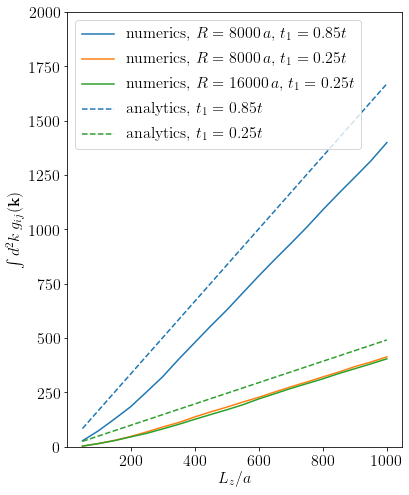

In [677]:
plt.figure(figsize=(6,8))
plt.plot(Lzs, D0, label='numerics, $R=8000\,a$, $t_1=0.85t$', c=colors[0], ls='-')
plt.plot(Lzs, D1, label='numerics, $R=8000\,a$, $t_1=0.25t$', c=colors[1], ls='-')
plt.plot(Lzs, D2, label='numerics, $R=16000\,a$, $t_1=0.25t$', c=colors[2], ls='-')
plt.plot(Lzs, scaling_factor0*Lzs, label='analytics, $t_1=0.85t$', c=colors[0], ls='--')
plt.plot(Lzs, scaling_factor2*Lzs, label='analytics, $t_1=0.25t$', c=colors[2], ls='--')
plt.xlabel('$L_z/a$')
plt.ylabel('$\int d^2 k\, g_{ij}(\mathbf{k})$')
#plt.yticks(ticks=[])
plt.ylim(0.0,2000)
plt.legend()

In [462]:
l=8
print(Lzs[l])

450


Text(0, 0.5, '$k_y$')

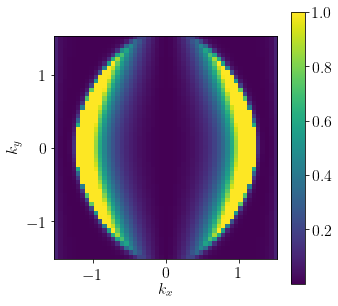

In [463]:
plt.figure(figsize=(5,5))
plt.imshow((gij1[l,0,0,:,:]).transpose(), 
           extent=tools.imshow_extent(kxs_ext,kys_ext), aspect=1, origin='lower', vmax=1)
plt.colorbar()
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

Text(0, 0.5, '$k_y$')

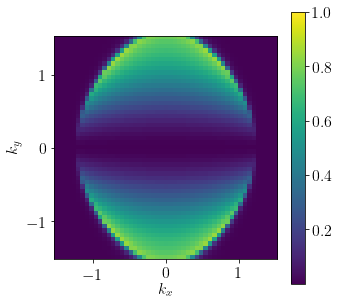

In [464]:
plt.figure(figsize=(5,5))
plt.imshow((gij1[l,1,1,:,:]).transpose(), 
           extent=tools.imshow_extent(kxs_ext,kys_ext), aspect=1, origin='lower', vmax=1)
plt.colorbar()
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

## Save to file for figures

In [679]:
params = dict(t1_0=t1_0, t1_1=t1_1, t1_2=t1_2, t2=t2, R0=R0, R1=R1, R2=R2,
              Nk=Nk, klim_0=1.5, klim_1=0.8, klim_2=0.8, 
              cutoff0=cutoff0, cutoff1=cutoff1, cutoff2=cutoff2)

In [680]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'toy_model_stiffness_scaling'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(Lzs, fp)
pickle.dump(energies0_ext, fp)
pickle.dump(energies1_ext, fp)
pickle.dump(energies2_ext, fp)
pickle.dump(gij0, fp)
pickle.dump(gij1, fp)
pickle.dump(gij2, fp)
pickle.dump(Dij0, fp)
pickle.dump(Dij1, fp)
pickle.dump(Dij2, fp)
#fp.close()